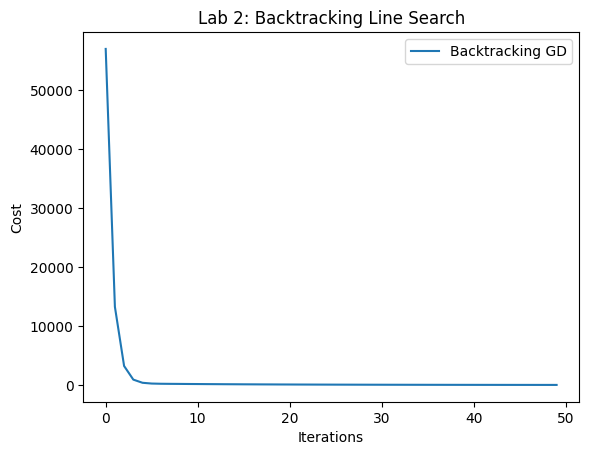

Final Model: y = 147.58x + 8.36


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset (House size vs Price)
X = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([150, 300, 450, 600, 750], dtype=float)

def compute_cost(X, y, m, c):
    y_pred = m * X + c
    return np.mean((y - y_pred) ** 2)

def gradient_descent_backtracking(X, y, initial_lr=1.0, iterations=150, shrink_factor=0.5):
    m, c = 0, 0
    costs = []

    for _ in range(iterations):
        y_pred = m * X + c


        # Gradients
        dm = -2 * np.mean(X * (y - y_pred))
        dc = (-2) * np.mean(y - y_pred)

        # Backtracking: find good step size
        step = initial_lr
        cost = compute_cost(X, y, m, c)
        while True:
            new_m = m - step * dm
            new_c = c - step * dc
            new_cost = compute_cost(X, y, new_m, new_c)

            if new_cost < cost:  # success, accept step
                m, c = new_m, new_c
                cost = new_cost
                break
            else:
                step *= shrink_factor  # reduce step size

        costs.append(cost)

    return m, c, costs

# Run Backtracking GD
m_bt, c_bt, costs_bt = gradient_descent_backtracking(X, y, initial_lr=1.0, iterations=50)

plt.plot(costs_bt, label="Backtracking GD")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Lab 2: Backtracking Line Search")
plt.legend()
plt.show()

print(f"Final Model: y = {m_bt:.2f}x + {c_bt:.2f}")
